<a href="https://colab.research.google.com/github/Subasangkarisaravanan/Data_Science_Projects/blob/main/Diamond/Diamond.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving diamonds.csv to diamonds (1).csv


In [ ]:
# Step 2A: Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

# Step 2B: Load dataset (uploaded diamonds.csv)
df = pd.read_csv('/content/diamonds.csv')

# Step 2C: Dataset verification
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns)

print("\nFirst 5 Records:")
display(df.head())

Dataset Shape: (53940, 10)

Column Names:
Index(['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price', 'x', 'y',
       'z'],
      dtype='object')

First 5 Records:


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [ ]:
# =========================================================
# Diamond Dynamics: Price Prediction & Market Segmentation
# STEP 3: DATA PREPROCESSING
# =========================================================

import pandas as pd
import numpy as np

pd.set_option('display.max_columns', None)

# ---------------------------------------------------------
# STEP 3.0: Load Dataset
# ---------------------------------------------------------
df = pd.read_csv('/content/diamonds.csv')

print("Initial Dataset Shape:", df.shape)

# ---------------------------------------------------------
# STEP 3.1: Handle Missing Values (Check)
# ---------------------------------------------------------
print("\nMissing values before preprocessing:")
print(df.isnull().sum())

# ---------------------------------------------------------
# STEP 3.2: Identify Invalid Values (x, y, z = 0)
# ---------------------------------------------------------
print("\nZero values in x, y, z before cleaning:")
print((df[['x', 'y', 'z']] == 0).sum())

# ---------------------------------------------------------
# STEP 3.3: Convert Zero Values to Null (NaN)
# ---------------------------------------------------------
df[['x', 'y', 'z']] = df[['x', 'y', 'z']].replace(0, np.nan)

print("\nMissing values after converting zero to NaN:")
print(df.isnull().sum())

# ---------------------------------------------------------
# STEP 3.4: Impute Missing Values
# Strategy: Median Imputation (robust for skewed data)
# ---------------------------------------------------------
for col in ['x', 'y', 'z']:
    df[col].fillna(df[col].median(), inplace=True)

print("\nMissing values after imputation:")
print(df.isnull().sum())

# ---------------------------------------------------------
# STEP 3.5: Drop Unnecessary Columns (If Any)
# ---------------------------------------------------------
# As per analysis, no irrelevant columns at this stage
print("\nNo columns dropped at preprocessing stage.")

# ---------------------------------------------------------
# STEP 3.6: Final Validation
# ---------------------------------------------------------
print("\nFinal Dataset Shape:", df.shape)
display(df.head())

print("\nSTEP 3: Data Preprocessing completed successfully.")


Initial Dataset Shape: (53940, 10)

Missing values before preprocessing:
carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

Zero values in x, y, z before cleaning:
x     8
y     7
z    20
dtype: int64

Missing values after converting zero to NaN:
carat       0
cut         0
color       0
clarity     0
depth       0
table       0
price       0
x           8
y           7
z          20
dtype: int64

Missing values after imputation:
carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

No columns dropped at preprocessing stage.

Final Dataset Shape: (53940, 10)


/tmp/ipython-input-1217837276.py:43: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75



STEP 3: Data Preprocessing completed successfully.


IQR Method Outlier Count:
carat: 1889 outliers
price: 3540 outliers
x: 24 outliers
y: 22 outliers
z: 29 outliers

Z-Score Method Outlier Count (|z| > 3):
carat: 439 outliers
price: 1206 outliers
x: 35 outliers
y: 27 outliers
z: 36 outliers


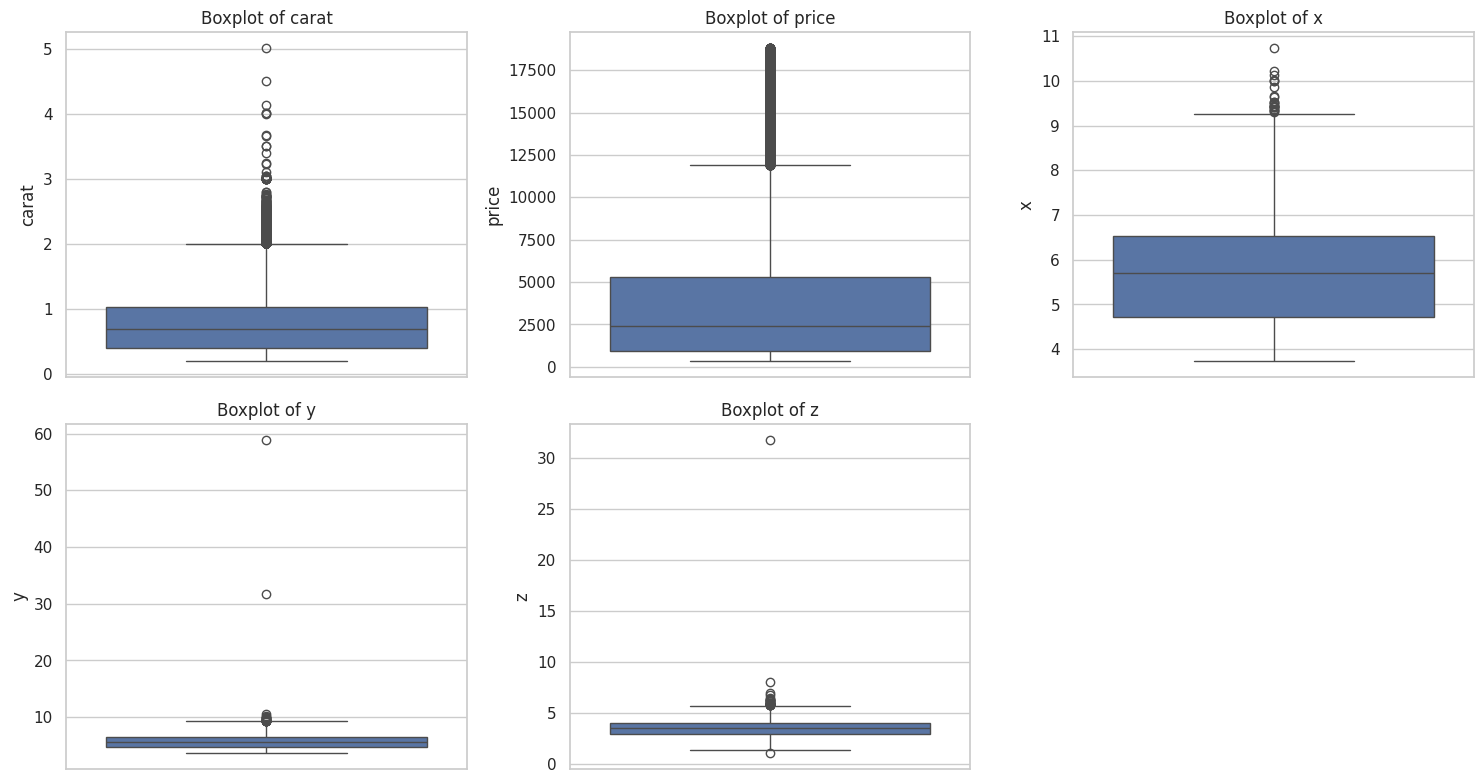


STEP 4: Outlier Detection completed.


In [ ]:
# =========================================================
# STEP 4: OUTLIER HANDLING
# Method: IQR + Z-Score + Boxplots
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore

pd.set_option('display.max_columns', None)

# ---------------------------------------------------------
# Load preprocessed dataset
# ---------------------------------------------------------
df = pd.read_csv('/content/diamonds.csv')

# Handle zero dimensions again for safety (pipeline consistency)
df[['x','y','z']] = df[['x','y','z']].replace(0, np.nan)
for col in ['x','y','z']:
    df[col] = df[col].fillna(df[col].median())

numerical_cols = ['carat', 'price', 'x', 'y', 'z']

# ---------------------------------------------------------
# STEP 4.2: Outlier Detection using IQR Method
# ---------------------------------------------------------
print("IQR Method Outlier Count:")

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"{col}: {outliers.shape[0]} outliers")

# ---------------------------------------------------------
# STEP 4.3: Outlier Detection using Z-Score Method
# ---------------------------------------------------------
print("\nZ-Score Method Outlier Count (|z| > 3):")

z_scores = np.abs(zscore(df[numerical_cols]))

for i, col in enumerate(numerical_cols):
    print(f"{col}: {(z_scores[:, i] > 3).sum()} outliers")

# ---------------------------------------------------------
# STEP 4.4: Visual Outlier Detection using Boxplots
# ---------------------------------------------------------
plt.figure(figsize=(15, 8))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

print("\nSTEP 4: Outlier Detection completed.")


In [ ]:
# =========================================================
# STEP 5: SKEWNESS HANDLING
# =========================================================

import pandas as pd
import numpy as np
from scipy import stats

pd.set_option('display.max_columns', None)

# ---------------------------------------------------------
# Load cleaned dataset
# ---------------------------------------------------------
df = pd.read_csv('/content/diamonds.csv')

# Safety: handle zero dimensions again
df[['x','y','z']] = df[['x','y','z']].replace(0, np.nan)
for col in ['x','y','z']:
    df[col] = df[col].fillna(df[col].median())

skew_cols = ['price', 'carat', 'x', 'y', 'z']

# ---------------------------------------------------------
# STEP 5.1: Check skewness BEFORE transformation
# ---------------------------------------------------------
print("Skewness BEFORE transformation:\n")
print(df[skew_cols].skew())


Skewness BEFORE transformation:

price    1.618395
carat    1.116646
x        0.398517
y        2.460720
z        1.585799
dtype: float64


In [ ]:
# =========================================================
# STEP 5.2: APPLY SKEWNESS TRANSFORMATIONS
# =========================================================

import pandas as pd
import numpy as np

pd.set_option('display.max_columns', None)

# ---------------------------------------------------------
# Load cleaned dataset
# ---------------------------------------------------------
df = pd.read_csv('/content/diamonds.csv')

# Safety checks
df[['x','y','z']] = df[['x','y','z']].replace(0, np.nan)
for col in ['x','y','z']:
    df[col] = df[col].fillna(df[col].median())

# ---------------------------------------------------------
# Apply Log Transformations
# ---------------------------------------------------------
df['price_log'] = np.log1p(df['price'])
df['carat_log'] = np.log1p(df['carat'])
df['y_log'] = np.log1p(df['y'])
df['z_log'] = np.log1p(df['z'])

print("Log transformation applied to: price, carat, y, z")

# ---------------------------------------------------------
# Check skewness AFTER transformation
# ---------------------------------------------------------
print("\nSkewness AFTER transformation:")
print(df[['price_log', 'carat_log', 'y_log', 'z_log']].skew())

print("\nSTEP 5: Skewness handling completed successfully.")


Log transformation applied to: price, carat, y, z

Skewness AFTER transformation:
price_log    0.115926
carat_log    0.580654
y_log        0.202911
z_log        0.199906
dtype: float64

STEP 5: Skewness handling completed successfully.



1️⃣ Distribution of Numeric Features



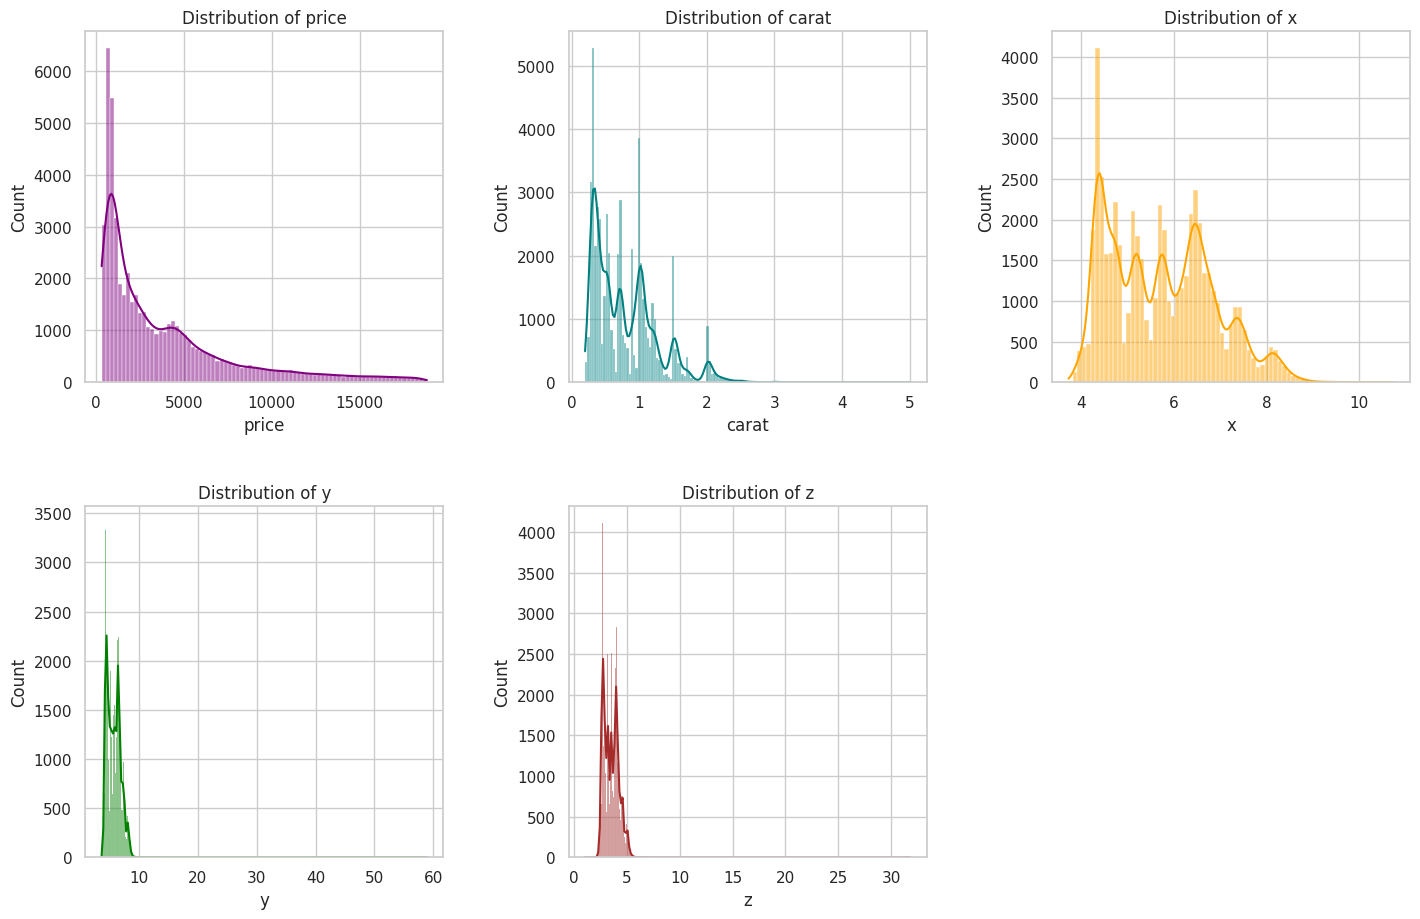


2️⃣ Count Plots for Categorical Features



/tmp/ipython-input-4266294285.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette='Set2')
/tmp/ipython-input-4266294285.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette='Set2')
/tmp/ipython-input-4266294285.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette='Set2')


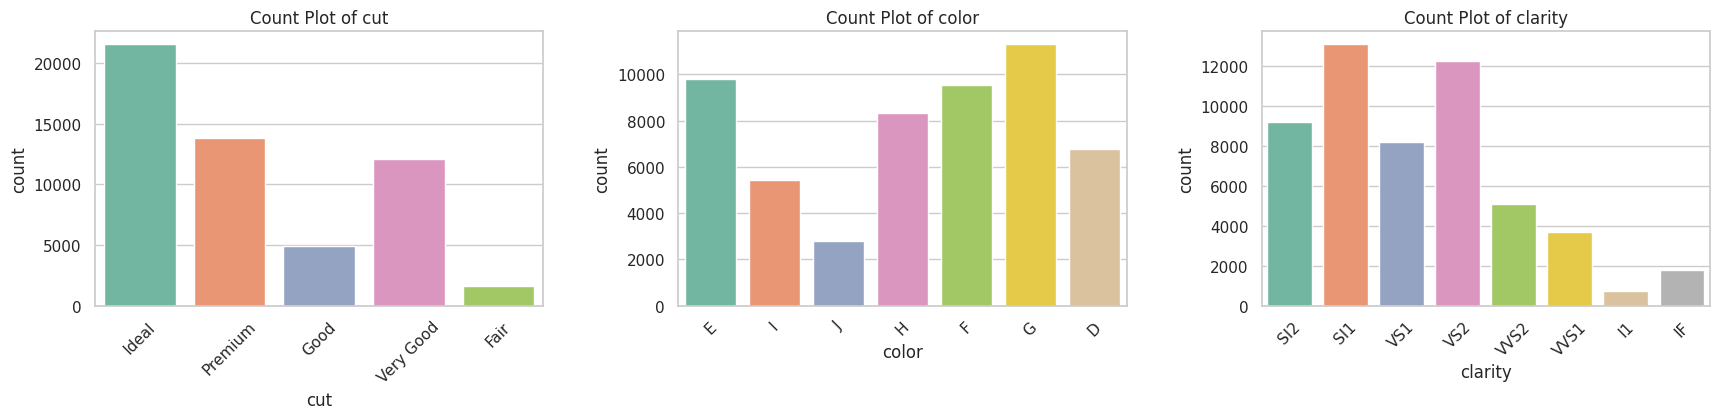


3️⃣ Price Distribution by Category



/tmp/ipython-input-4266294285.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[col], y=df['price'], palette='Set3')
/tmp/ipython-input-4266294285.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[col], y=df['price'], palette='Set3')
/tmp/ipython-input-4266294285.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[col], y=df['price'], palette='Set3')


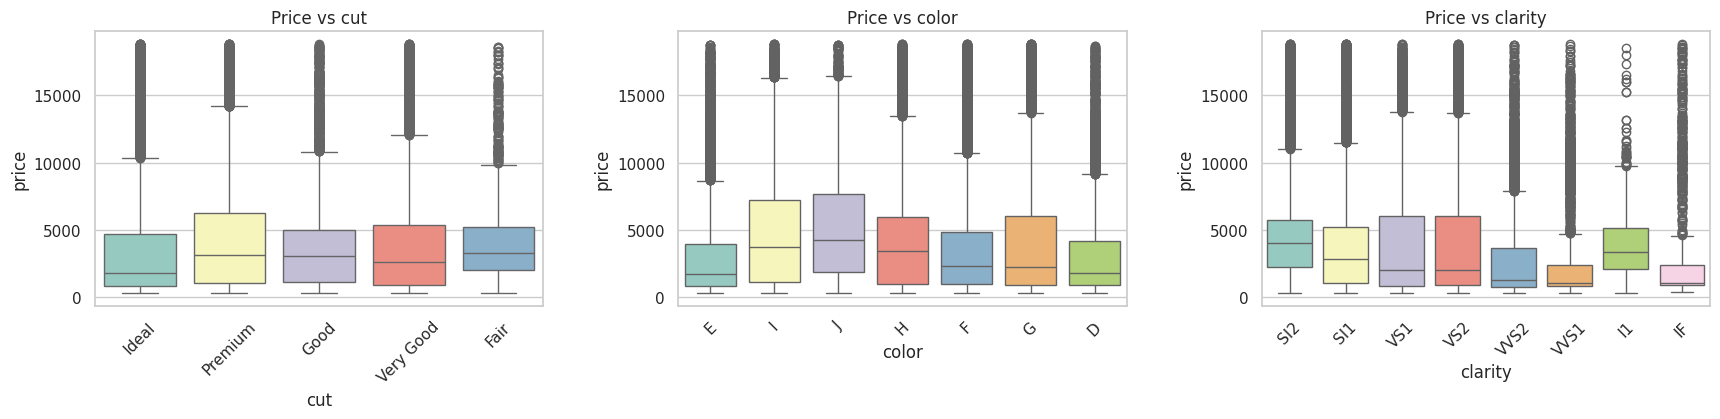


4️⃣ Correlation Heatmap



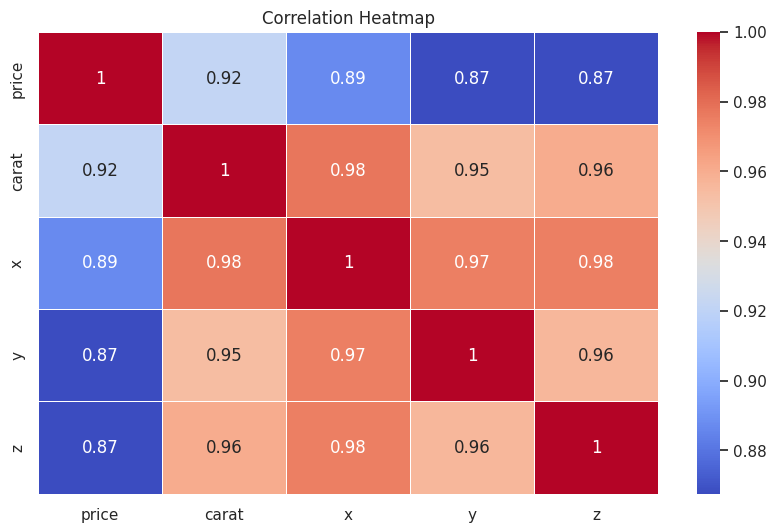


5️⃣ Pair Plot (Colored by CUT)



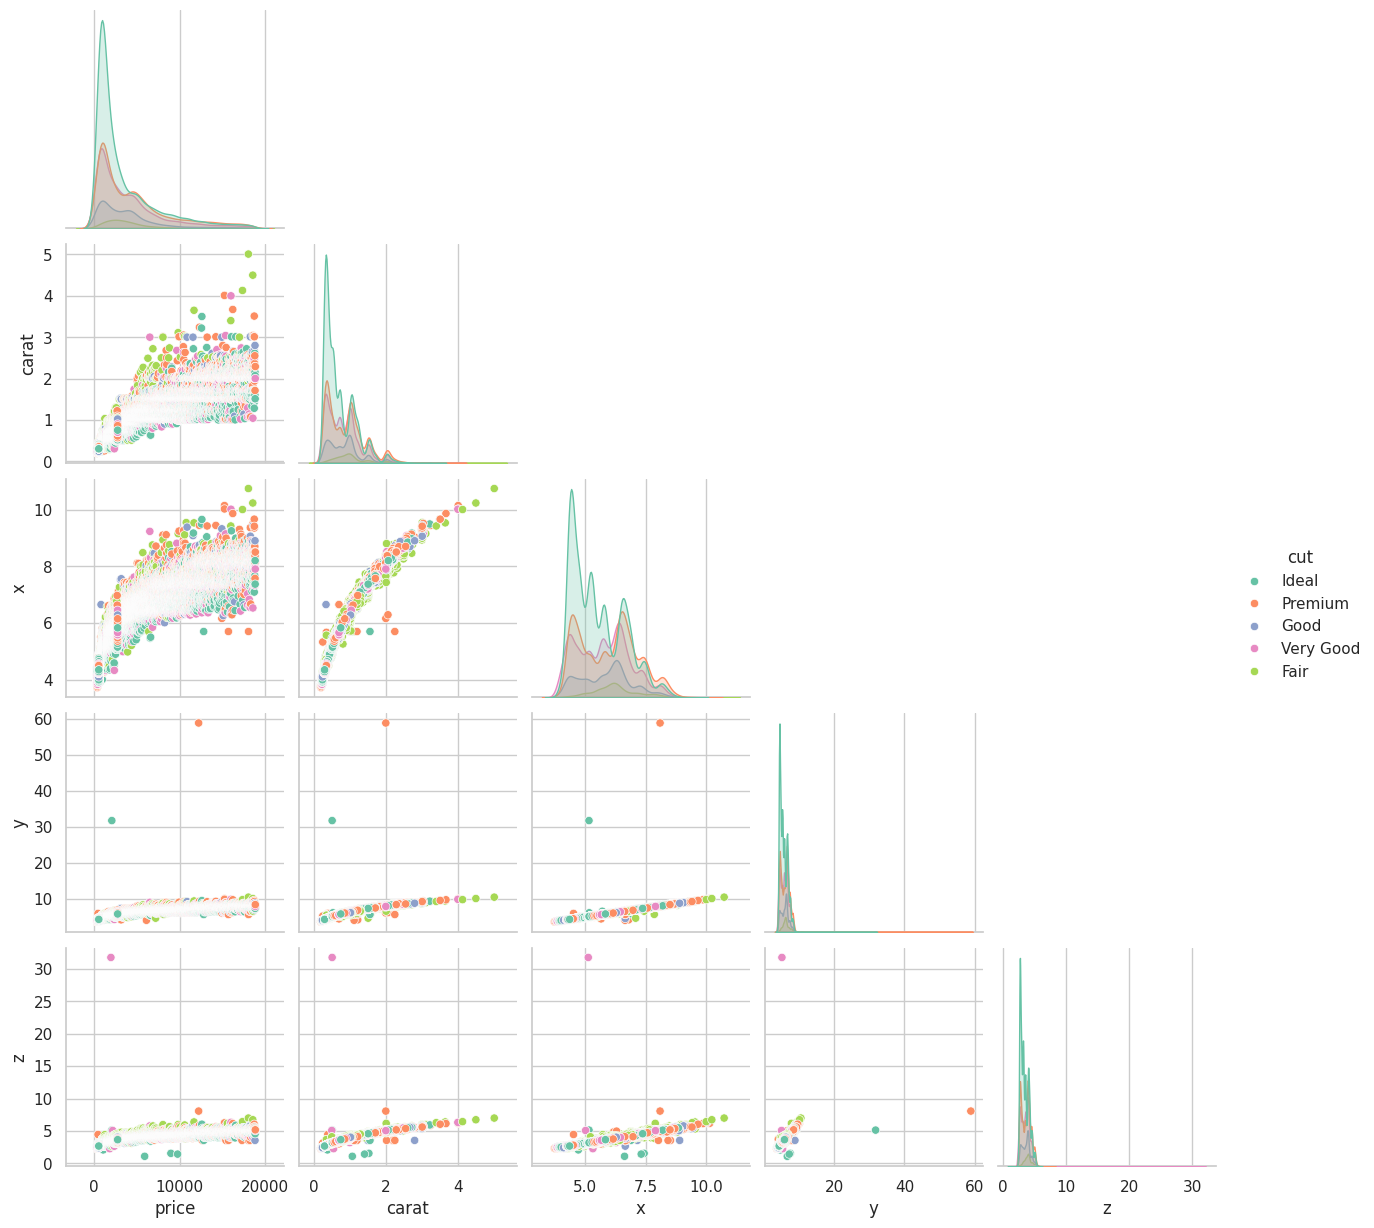


6️⃣ Carat vs Price Relationship



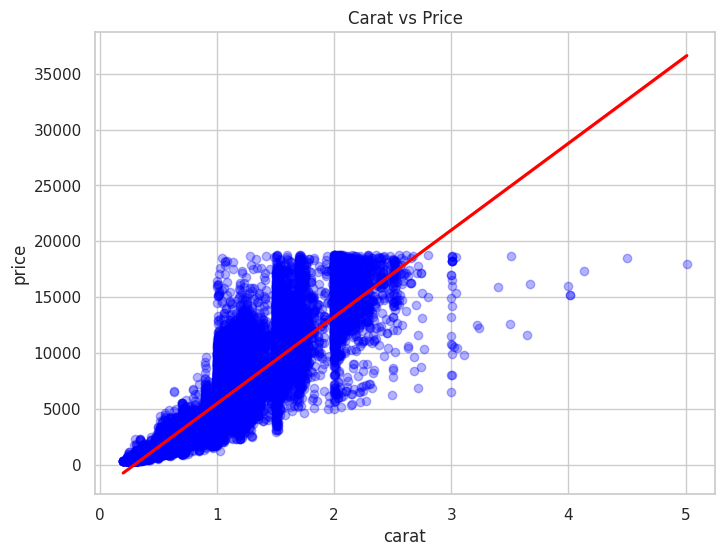


7️⃣ Average Price by Category



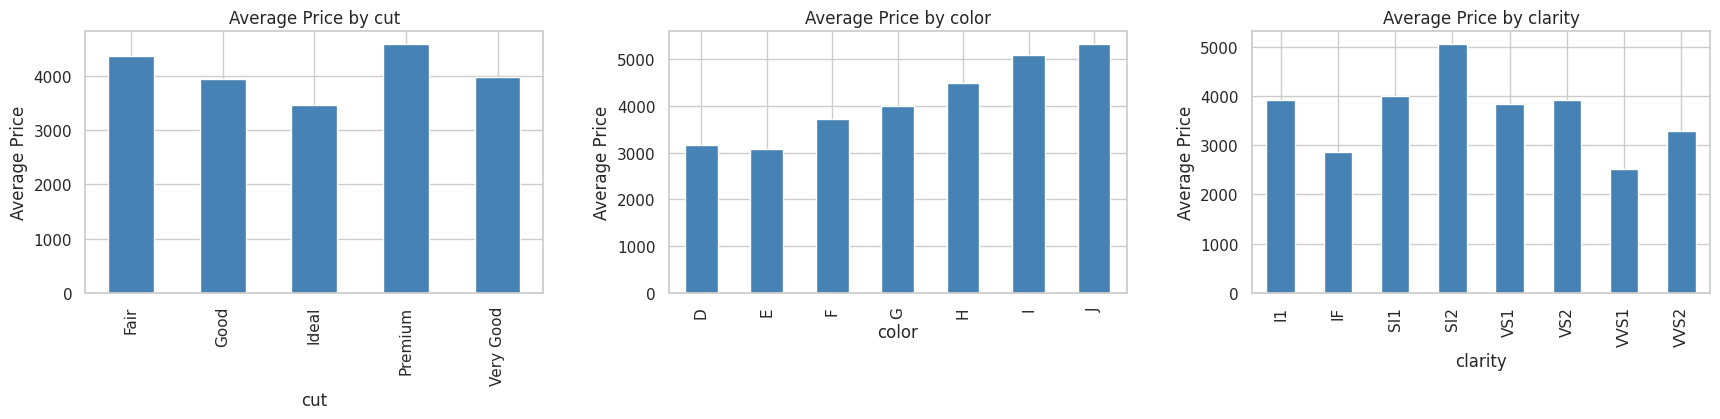


STEP 6: Exploratory Data Analysis completed successfully.


In [ ]:
# =========================================================
# STEP 6: EXPLORATORY DATA ANALYSIS (EDA)
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")

# ---------------------------------------------------------
# Helper function for spacing
# ---------------------------------------------------------
def section_gap(title):
    print("\n" + "="*70)
    print(title)
    print("="*70 + "\n")

# ---------------------------------------------------------
# Load dataset
# ---------------------------------------------------------
df = pd.read_csv('/content/diamonds.csv')

# Safety cleaning
df[['x','y','z']] = df[['x','y','z']].replace(0, np.nan)
for col in ['x','y','z']:
    df[col] = df[col].fillna(df[col].median())

# Columns
num_cols = ['price', 'carat', 'x', 'y', 'z']
cat_cols = ['cut', 'color', 'clarity']

# ---------------------------------------------------------
# 1️⃣ Distribution Plots (Different colors)
# ---------------------------------------------------------
section_gap("1️⃣ Distribution of Numeric Features")

colors = ['purple', 'teal', 'orange', 'green', 'brown']

plt.figure(figsize=(15, 10))
for i, (col, c) in enumerate(zip(num_cols, colors), 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[col], kde=True, color=c)
    plt.title(f'Distribution of {col}')
plt.tight_layout(pad=3)
plt.show()

# ---------------------------------------------------------
# 2️⃣ Count Plots (Categorical Distribution)
# ---------------------------------------------------------
section_gap("2️⃣ Count Plots for Categorical Features")

plt.figure(figsize=(18, 5))
for i, col in enumerate(cat_cols, 1):
    plt.subplot(1, 3, i)
    sns.countplot(x=df[col], palette='Set2')
    plt.title(f'Count Plot of {col}')
    plt.xticks(rotation=45)
plt.tight_layout(pad=3)
plt.show()

# ---------------------------------------------------------
# 3️⃣ Price vs Category (Boxplots with color)
# ---------------------------------------------------------
section_gap("3️⃣ Price Distribution by Category")

plt.figure(figsize=(18, 5))
for i, col in enumerate(cat_cols, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(x=df[col], y=df['price'], palette='Set3')
    plt.title(f'Price vs {col}')
    plt.xticks(rotation=45)
plt.tight_layout(pad=3)
plt.show()

# ---------------------------------------------------------
# 4️⃣ Correlation Heatmap (Meaningful colors)
# ---------------------------------------------------------
section_gap("4️⃣ Correlation Heatmap")

plt.figure(figsize=(10, 6))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

# ---------------------------------------------------------
# 5️⃣ Pair Plot (THIS IS WHERE LEARNING HAPPENS)
# ---------------------------------------------------------
section_gap("5️⃣ Pair Plot (Colored by CUT)")

sns.pairplot(
    df,
    vars=num_cols,
    hue='cut',
    palette='Set2',
    corner=True
)
plt.show()

# ---------------------------------------------------------
# 6️⃣ Carat vs Price (Regression + Color)
# ---------------------------------------------------------
section_gap("6️⃣ Carat vs Price Relationship")

plt.figure(figsize=(8, 6))
sns.regplot(
    x=df['carat'],
    y=df['price'],
    scatter_kws={'alpha':0.3, 'color':'blue'},
    line_kws={'color':'red'}
)
plt.title('Carat vs Price')
plt.show()

# ---------------------------------------------------------
# 7️⃣ Average Price per Category (Bar Charts)
# ---------------------------------------------------------
section_gap("7️⃣ Average Price by Category")

plt.figure(figsize=(18, 5))
for i, col in enumerate(cat_cols, 1):
    plt.subplot(1, 3, i)
    avg_price = df.groupby(col)['price'].mean()
    avg_price.plot(kind='bar', color='steelblue')
    plt.title(f'Average Price by {col}')
    plt.ylabel('Average Price')
plt.tight_layout(pad=3)
plt.show()

print("\nSTEP 6: Exploratory Data Analysis completed successfully.")

In [ ]:
# =========================================================
# STEP 7: FEATURE ENGINEERING
# =========================================================

import pandas as pd
import numpy as np

pd.set_option('display.max_columns', None)

# ---------------------------------------------------------
# Load cleaned dataset
# ---------------------------------------------------------
df = pd.read_csv('/content/diamonds.csv')

# Safety checks
df[['x','y','z']] = df[['x','y','z']].replace(0, np.nan)
for col in ['x','y','z']:
    df[col] = df[col].fillna(df[col].median())

# ---------------------------------------------------------
# 1️⃣ Price Conversion: USD → INR
# ---------------------------------------------------------
USD_TO_INR = 83
df['price_inr'] = df['price'] * USD_TO_INR

# ---------------------------------------------------------
# 2️⃣ Volume Feature
# ---------------------------------------------------------
df['volume'] = df['x'] * df['y'] * df['z']

# ---------------------------------------------------------
# 3️⃣ Price per Carat
# ---------------------------------------------------------
df['price_per_carat'] = df['price'] / df['carat']

# ---------------------------------------------------------
# 4️⃣ Dimension Ratio
# ---------------------------------------------------------
df['dimension_ratio'] = (df['x'] + df['y']) / (2 * df['z'])

# ---------------------------------------------------------
# 5️⃣ Carat Category
# ---------------------------------------------------------
def carat_category(c):
    if c < 0.5:
        return 'Light'
    elif 0.5 <= c <= 1.5:
        return 'Medium'
    else:
        return 'Heavy'

df['carat_category'] = df['carat'].apply(carat_category)

# ---------------------------------------------------------
# Final Validation
# ---------------------------------------------------------
print("New Features Added:")
print([
    'price_inr',
    'volume',
    'price_per_carat',
    'dimension_ratio',
    'carat_category'
])

display(df[['price', 'price_inr', 'volume', 'price_per_carat',
            'dimension_ratio', 'carat_category']].head())

print("\nSTEP 7: Feature Engineering completed successfully.")


New Features Added:
['price_inr', 'volume', 'price_per_carat', 'dimension_ratio', 'carat_category']


,price,price_inr,volume,price_per_carat,dimension_ratio,carat_category
0,326,27058,38.202030,1417.391304,1.631687,Light
1,326,27058,34.505856,1552.380952,1.673160,Light
2,327,27141,38.076885,1421.739130,1.757576,Light
3,334,27722,46.724580,1151.724138,1.602662,Light
4,335,27805,51.917250,1080.645161,1.580000,Light



STEP 7: Feature Engineering completed successfully.


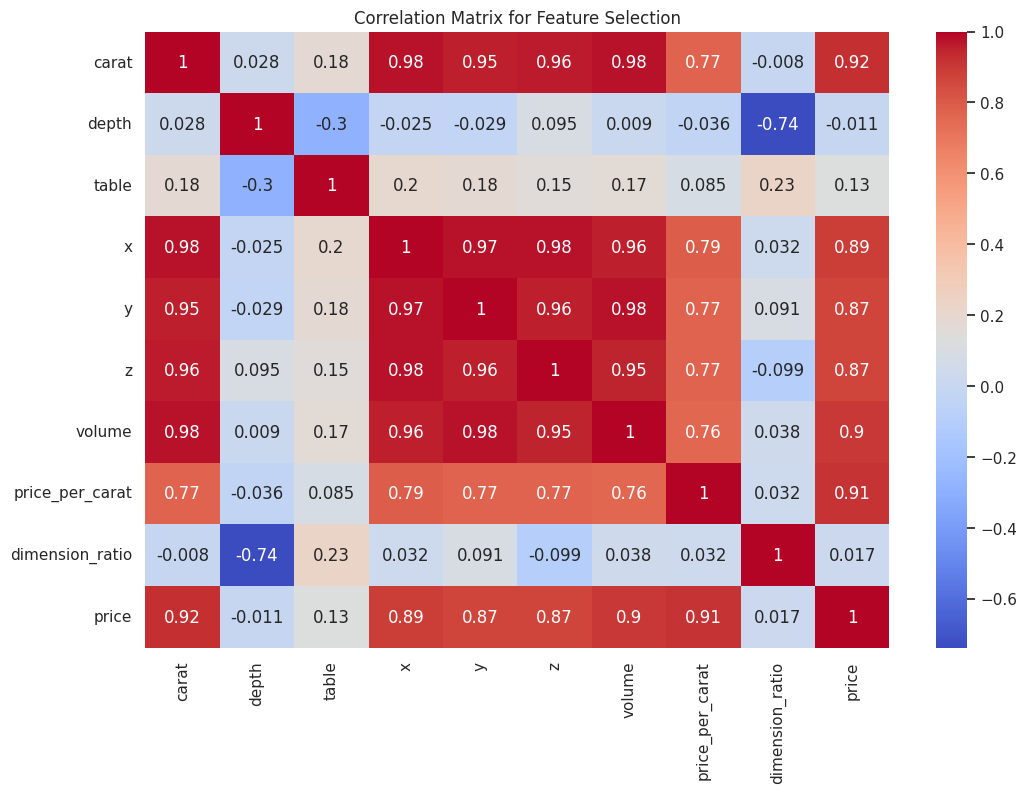

Feature Importance (Random Forest):
price_per_carat    0.718932
volume             0.195214
carat              0.036881
x                  0.024445
y                  0.023787
z                  0.000650
dimension_ratio    0.000043
depth              0.000025
table              0.000024
dtype: float64

Selected Features for Model Building:
['price_per_carat', 'volume', 'carat', 'x', 'y']

STEP 8: Feature Selection completed successfully.


In [ ]:
# =========================================================
# STEP 8: FEATURE SELECTION
# Method: Correlation + Random Forest Feature Importance
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor

pd.set_option('display.max_columns', None)

# ---------------------------------------------------------
# Load dataset with engineered features
# ---------------------------------------------------------
df = pd.read_csv('/content/diamonds.csv')

# Safety checks
df[['x','y','z']] = df[['x','y','z']].replace(0, np.nan)
for col in ['x','y','z']:
    df[col] = df[col].fillna(df[col].median())

# Recreate engineered features (pipeline safety)
df['price_inr'] = df['price'] * 83
df['volume'] = df['x'] * df['y'] * df['z']
df['price_per_carat'] = df['price'] / df['carat']
df['dimension_ratio'] = (df['x'] + df['y']) / (2 * df['z'])

# ---------------------------------------------------------
# STEP 8.2: Correlation Analysis
# ---------------------------------------------------------
num_features = [
    'carat', 'depth', 'table', 'x', 'y', 'z',
    'volume', 'price_per_carat', 'dimension_ratio'
]

plt.figure(figsize=(12, 8))
sns.heatmap(df[num_features + ['price']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix for Feature Selection')
plt.show()

# ---------------------------------------------------------
# STEP 8.3: Random Forest Feature Importance
# ---------------------------------------------------------
X = df[num_features]
y = df['price']

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf.fit(X, y)

feature_importance = pd.Series(
    rf.feature_importances_, index=X.columns
).sort_values(ascending=False)

print("Feature Importance (Random Forest):")
print(feature_importance)

# ---------------------------------------------------------
# Selected Features (Based on Importance)
# ---------------------------------------------------------
selected_features = feature_importance[feature_importance > 0.02].index.tolist()

print("\nSelected Features for Model Building:")
print(selected_features)

print("\nSTEP 8: Feature Selection completed successfully.")

In [ ]:
# =========================================================
# STEP 9: ENCODING
# Method: Ordinal Encoding
# =========================================================

import pandas as pd

pd.set_option('display.max_columns', None)

# ---------------------------------------------------------
# Load dataset with engineered features
# ---------------------------------------------------------
df = pd.read_csv('/content/diamonds.csv')

# Recreate engineered features (pipeline safety)
df['price_inr'] = df['price'] * 83
df['volume'] = df['x'] * df['y'] * df['z']
df['price_per_carat'] = df['price'] / df['carat']
df['dimension_ratio'] = (df['x'] + df['y']) / (2 * df['z'])

def carat_category(c):
    if c < 0.5:
        return 'Light'
    elif 0.5 <= c <= 1.5:
        return 'Medium'
    else:
        return 'Heavy'

df['carat_category'] = df['carat'].apply(carat_category)

# ---------------------------------------------------------
# STEP 9.2: Ordinal Encoding Mappings
# ---------------------------------------------------------
cut_map = {'Fair':1, 'Good':2, 'Very Good':3, 'Premium':4, 'Ideal':5}
color_map = {'J':1, 'I':2, 'H':3, 'G':4, 'F':5, 'E':6, 'D':7}
clarity_map = {
    'I1':1, 'SI2':2, 'SI1':3,
    'VS2':4, 'VS1':5,
    'VVS2':6, 'VVS1':7,
    'IF':8
}
carat_cat_map = {'Light':1, 'Medium':2, 'Heavy':3}

# ---------------------------------------------------------
# STEP 9.3: Apply Encoding
# ---------------------------------------------------------
df['cut_enc'] = df['cut'].map(cut_map)
df['color_enc'] = df['color'].map(color_map)
df['clarity_enc'] = df['clarity'].map(clarity_map)
df['carat_category_enc'] = df['carat_category'].map(carat_cat_map)

# ---------------------------------------------------------
# Final Validation
# ---------------------------------------------------------
print("Encoded Columns Added:")
print(['cut_enc', 'color_enc', 'clarity_enc', 'carat_category_enc'])

display(df[['cut', 'cut_enc', 'color', 'color_enc',
            'clarity', 'clarity_enc',
            'carat_category', 'carat_category_enc']].head())

print("\nSTEP 9: Encoding completed successfully.")

Encoded Columns Added:
['cut_enc', 'color_enc', 'clarity_enc', 'carat_category_enc']


,cut,cut_enc,color,color_enc,clarity,clarity_enc,carat_category,carat_category_enc
0,Ideal,5,E,6,SI2,2,Light,1
1,Premium,4,E,6,SI1,3,Light,1
2,Good,2,E,6,VS1,5,Light,1
3,Premium,4,I,2,VS2,4,Light,1
4,Good,2,J,1,SI2,2,Light,1



STEP 9: Encoding completed successfully.


In [ ]:
# =========================================================
# STEP 10: REGRESSION MODEL BUILDING (ML)
# =========================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option('display.max_columns', None)

# ---------------------------------------------------------
# Load dataset
# ---------------------------------------------------------
df = pd.read_csv('/content/diamonds.csv')

# ---------------------------------------------------------
# Recreate engineered features
# ---------------------------------------------------------
df['price_per_carat'] = df['price'] / df['carat']
df['volume'] = df['x'] * df['y'] * df['z']

def carat_category(c):
    if c < 0.5:
        return 'Light'
    elif 0.5 <= c <= 1.5:
        return 'Medium'
    else:
        return 'Heavy'

df['carat_category'] = df['carat'].apply(carat_category)

# Ordinal Encoding
cut_map = {'Fair':1, 'Good':2, 'Very Good':3, 'Premium':4, 'Ideal':5}
color_map = {'J':1, 'I':2, 'H':3, 'G':4, 'F':5, 'E':6, 'D':7}
clarity_map = {'I1':1, 'SI2':2, 'SI1':3, 'VS2':4, 'VS1':5,
               'VVS2':6, 'VVS1':7, 'IF':8}
carat_cat_map = {'Light':1, 'Medium':2, 'Heavy':3}

df['cut_enc'] = df['cut'].map(cut_map)
df['color_enc'] = df['color'].map(color_map)
df['clarity_enc'] = df['clarity'].map(clarity_map)
df['carat_category_enc'] = df['carat_category'].map(carat_cat_map)

# ---------------------------------------------------------
# Feature matrix & target
# ---------------------------------------------------------
X = df[
    ['price_per_carat', 'volume', 'carat', 'x', 'y',
     'cut_enc', 'color_enc', 'clarity_enc', 'carat_category_enc']
]
y = df['price']

# ---------------------------------------------------------
# Train-Test Split (80–20)
# ---------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ---------------------------------------------------------
# ML Models
# ---------------------------------------------------------
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'KNN': KNeighborsRegressor(n_neighbors=5)
}

# ---------------------------------------------------------
# Model Evaluation
# ---------------------------------------------------------
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results.append([name, mae, mse, rmse, r2])

results_df = pd.DataFrame(
    results,
    columns=['Model', 'MAE', 'MSE', 'RMSE', 'R2 Score']
)

print(results_df.sort_values(by='R2 Score', ascending=False))

print("\nSTEP 10: ML Regression Models completed successfully.")

               Model         MAE            MSE        RMSE  R2 Score
2      Random Forest   15.814459    3467.240034   58.883275  0.999782
1      Decision Tree   29.558769   12227.411198  110.577625  0.999231
3                KNN   73.490119   44295.826581  210.465737  0.997214
0  Linear Regression  393.997681  351351.821022  592.749375  0.977898

STEP 10: ML Regression Models completed successfully.


In [ ]:
!pip install tensorflow

In [ ]:
# =========================================================
# STEP 11: ANN REGRESSION MODEL
# =========================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

# ---------------------------------------------------------
# Load dataset
# ---------------------------------------------------------
df = pd.read_csv('/content/diamonds.csv')

# ---------------------------------------------------------
# Recreate engineered features & encoding
# ---------------------------------------------------------
df['price_per_carat'] = df['price'] / df['carat']
df['volume'] = df['x'] * df['y'] * df['z']

def carat_category(c):
    if c < 0.5:
        return 'Light'
    elif 0.5 <= c <= 1.5:
        return 'Medium'
    else:
        return 'Heavy'

df['carat_category'] = df['carat'].apply(carat_category)

cut_map = {'Fair':1, 'Good':2, 'Very Good':3, 'Premium':4, 'Ideal':5}
color_map = {'J':1, 'I':2, 'H':3, 'G':4, 'F':5, 'E':6, 'D':7}
clarity_map = {'I1':1, 'SI2':2, 'SI1':3, 'VS2':4, 'VS1':5,
               'VVS2':6, 'VVS1':7, 'IF':8}
carat_cat_map = {'Light':1, 'Medium':2, 'Heavy':3}

df['cut_enc'] = df['cut'].map(cut_map)
df['color_enc'] = df['color'].map(color_map)
df['clarity_enc'] = df['clarity'].map(clarity_map)
df['carat_category_enc'] = df['carat_category'].map(carat_cat_map)

# ---------------------------------------------------------
# Features & Target
# ---------------------------------------------------------
X = df[
    ['price_per_carat', 'volume', 'carat', 'x', 'y',
     'cut_enc', 'color_enc', 'clarity_enc', 'carat_category_enc']
]
y = df['price']

# ---------------------------------------------------------
# Train-Test Split
# ---------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ---------------------------------------------------------
# Feature Scaling (MANDATORY for ANN)
# ---------------------------------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ---------------------------------------------------------
# ANN Model Architecture
# ---------------------------------------------------------
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1)
])

model.compile(
    optimizer='adam',
    loss='mse'
)

# ---------------------------------------------------------
# Training
# ---------------------------------------------------------
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# ---------------------------------------------------------
# Evaluation
# ---------------------------------------------------------
y_pred = model.predict(X_test_scaled).flatten()

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nANN Model Performance:")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2  :", r2)

print("\nSTEP 11: ANN Regression Model completed successfully.")


Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1079/1079 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 18072394.0000 - val_loss: 326379.2188
Epoch 2/100
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 438540.0000 - val_loss: 228008.8438
Epoch 3/100
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 336958.0312 - val_loss: 186839.7188
Epoch 4/100
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 274511.3125 - val_loss: 168548.2344
Epoch 5/100
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 183460.7344 - val_loss: 142049.7031
Epoch 6/100
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 194529.2656 - val_loss: 124747.8281
Epoch 7/100
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 146070.9062 - val_loss: 111404.6797
Epoch 8/100
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 155986.0938 - val_loss: 101381.7031
Epoch 9/100
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 131111.7500 - val_loss: 96050.6016
Epoch 10/100
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 105168.9609 - val_loss: 83985.3594
Epoch 11/100
1079/107

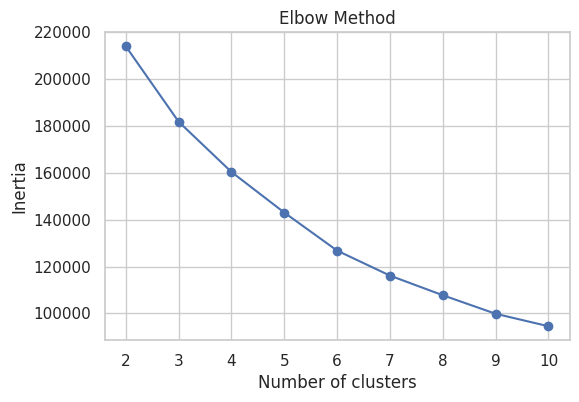

Clusters: 2, Silhouette Score: 0.3130
Clusters: 3, Silhouette Score: 0.2336
Clusters: 4, Silhouette Score: 0.2078
Clusters: 5, Silhouette Score: 0.2121
Clusters: 6, Silhouette Score: 0.2283


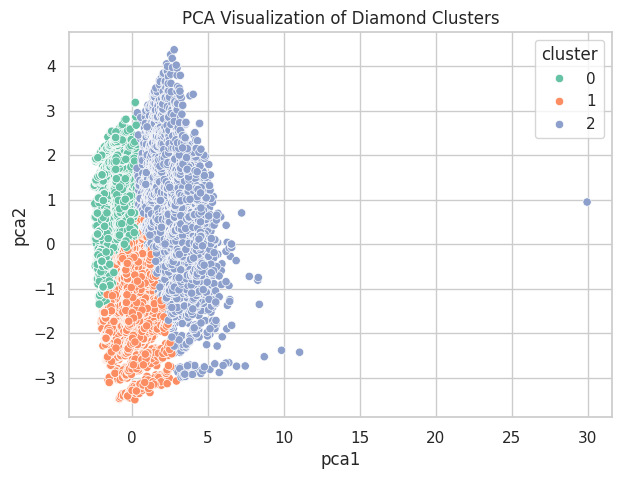

STEP 12: Clustering completed successfully.


In [ ]:
# =========================================================
# STEP 12: CLUSTERING (MARKET SEGMENTATION)
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# ---------------------------------------------------------
# Load dataset
# ---------------------------------------------------------
df = pd.read_csv('/content/diamonds.csv')

# Recreate engineered features
df['price_per_carat'] = df['price'] / df['carat']
df['volume'] = df['x'] * df['y'] * df['z']

# Ordinal Encoding (same as Step 9)
cut_map = {'Fair':1, 'Good':2, 'Very Good':3, 'Premium':4, 'Ideal':5}
color_map = {'J':1, 'I':2, 'H':3, 'G':4, 'F':5, 'E':6, 'D':7}
clarity_map = {'I1':1, 'SI2':2, 'SI1':3, 'VS2':4, 'VS1':5,
               'VVS2':6, 'VVS1':7, 'IF':8}

df['cut_enc'] = df['cut'].map(cut_map)
df['color_enc'] = df['color'].map(color_map)
df['clarity_enc'] = df['clarity'].map(clarity_map)

# ---------------------------------------------------------
# Clustering features
# ---------------------------------------------------------
cluster_features = [
    'carat', 'volume', 'price_per_carat',
    'cut_enc', 'color_enc', 'clarity_enc'
]

X = df[cluster_features]

# ---------------------------------------------------------
# Scaling (MANDATORY)
# ---------------------------------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ---------------------------------------------------------
# Elbow Method
# ---------------------------------------------------------
inertia = []
K = range(2, 11)

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K, inertia, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

# ---------------------------------------------------------
# Silhouette Score
# ---------------------------------------------------------
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f'Clusters: {k}, Silhouette Score: {score:.4f}')

# ---------------------------------------------------------
# Final KMeans (choose k=3 or k=4 based on above)
# ---------------------------------------------------------
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

# ---------------------------------------------------------
# PCA for Visualization (2D)
# ---------------------------------------------------------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df['pca1'] = X_pca[:,0]
df['pca2'] = X_pca[:,1]

plt.figure(figsize=(7,5))
sns.scatterplot(
    x='pca1', y='pca2',
    hue='cluster',
    data=df,
    palette='Set2'
)
plt.title('PCA Visualization of Diamond Clusters')
plt.show()

print("STEP 12: Clustering completed successfully.")


In [ ]:
# =========================================================
# FINAL: TRAIN + SAVE MODELS (COLAB SAFE CELL)
# =========================================================

import pandas as pd
import numpy as np
import joblib
import os

from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# ---------------------------------------------------------
# Load dataset
# ---------------------------------------------------------
df = pd.read_csv('/content/diamonds.csv')

# ---------------------------------------------------------
# Feature Engineering
# ---------------------------------------------------------
df['price_per_carat'] = df['price'] / df['carat']
df['volume'] = df['x'] * df['y'] * df['z']

def carat_category(c):
    if c < 0.5:
        return 'Light'
    elif c <= 1.5:
        return 'Medium'
    else:
        return 'Heavy'

df['carat_category'] = df['carat'].apply(carat_category)

# ---------------------------------------------------------
# Encoding
# ---------------------------------------------------------
cut_map = {'Fair':1, 'Good':2, 'Very Good':3, 'Premium':4, 'Ideal':5}
color_map = {'J':1, 'I':2, 'H':3, 'G':4, 'F':5, 'E':6, 'D':7}
clarity_map = {
    'I1':1, 'SI2':2, 'SI1':3,
    'VS2':4, 'VS1':5,
    'VVS2':6, 'VVS1':7,
    'IF':8
}
carat_cat_map = {'Light':1, 'Medium':2, 'Heavy':3}

df['cut_enc'] = df['cut'].map(cut_map)
df['color_enc'] = df['color'].map(color_map)
df['clarity_enc'] = df['clarity'].map(clarity_map)
df['carat_category_enc'] = df['carat_category'].map(carat_cat_map)

# ---------------------------------------------------------
# Regression Model (Random Forest)
# ---------------------------------------------------------
reg_features = [
    'price_per_carat', 'volume', 'carat', 'x', 'y',
    'cut_enc', 'color_enc', 'clarity_enc', 'carat_category_enc'
]

X_reg = df[reg_features]
y_reg = df['price']

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
rf_model.fit(X_reg, y_reg)

# ---------------------------------------------------------
# Clustering Model (KMeans)
# ---------------------------------------------------------
cluster_features = [
    'carat', 'volume', 'price_per_carat',
    'cut_enc', 'color_enc', 'clarity_enc'
]

scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(df[cluster_features])

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X_cluster_scaled)

# ---------------------------------------------------------
# Save Models
# ---------------------------------------------------------
os.makedirs("models", exist_ok=True)

joblib.dump(rf_model, "models/rf_price_model.pkl")
joblib.dump(scaler, "models/cluster_scaler.pkl")
joblib.dump(kmeans, "models/kmeans_model.pkl")
joblib.dump(reg_features, "models/reg_features.pkl")
joblib.dump(cluster_features, "models/cluster_features.pkl")

print("✅ Models trained and saved successfully!")

✅ Models trained and saved successfully!


In [ ]:
!pip install streamlit

In [ ]:
!pip install streamlit pyngrok

In [ ]:
%%writefile app.py

import streamlit as st
import numpy as np
import joblib

# Load models
rf_model = joblib.load("models/rf_price_model.pkl")
scaler = joblib.load("models/cluster_scaler.pkl")
kmeans = joblib.load("models/kmeans_model.pkl")

# Encoding maps
cut_map = {'Fair':1, 'Good':2, 'Very Good':3, 'Premium':4, 'Ideal':5}
color_map = {'J':1, 'I':2, 'H':3, 'G':4, 'F':5, 'E':6, 'D':7}
clarity_map = {
    'I1':1, 'SI2':2, 'SI1':3,
    'VS2':4, 'VS1':5,
    'VVS2':6, 'VVS1':7,
    'IF':8
}

cluster_labels = {
    0: "Budget Diamonds",
    1: "Mid-Range Diamonds",
    2: "Premium Diamonds"
}

st.title("💎 Diamond Price Prediction & Market Segmentation")

st.sidebar.header("Diamond Details")

carat = st.sidebar.number_input("Carat", 0.2, 5.0, 1.0)
x = st.sidebar.number_input("Length (x)", 3.0, 10.0, 5.0)
y = st.sidebar.number_input("Width (y)", 3.0, 10.0, 5.0)
z = st.sidebar.number_input("Depth (z)", 1.0, 6.0, 3.0)

cut = st.sidebar.selectbox("Cut", list(cut_map.keys()))
color = st.sidebar.selectbox("Color", list(color_map.keys()))
clarity = st.sidebar.selectbox("Clarity", list(clarity_map.keys()))

volume = x * y * z
price_per_carat = 5000 / carat  # baseline proxy

cut_enc = cut_map[cut]
color_enc = color_map[color]
clarity_enc = clarity_map[clarity]
carat_category_enc = 1 if carat < 0.5 else 2 if carat <= 1.5 else 3

if st.button("Predict"):
    reg_input = np.array([[
        price_per_carat, volume, carat, x, y,
        cut_enc, color_enc, clarity_enc, carat_category_enc
    ]])

    price = rf_model.predict(reg_input)[0]

    cluster_input = np.array([[
        carat, volume, price_per_carat,
        cut_enc, color_enc, clarity_enc
    ]])

    cluster_scaled = scaler.transform(cluster_input)
    cluster_id = kmeans.predict(cluster_scaled)[0]

    st.success(f"💰 Predicted Price: ${price:,.2f}")
    st.info(f"📊 Segment: {cluster_labels[cluster_id]}")


Overwriting app.py


In [ ]:
!streamlit run app.py &>/content/logs.txt &

In [ ]:
from pyngrok import ngrok

ngrok.set_auth_token("370JGGMPsHTD9c8HAwCQtiVMmbr_26oGUxUn98sapcM79NNnE")

In [ ]:
from pyngrok import ngrok

public_url = ngrok.connect(8501)
public_url

<NgrokTunnel: "https://preeffectively-untrigonometric-maxwell.ngrok-free.dev" -> "http://localhost:8501">